In [ ]:
import sys
import math
import matplotlib.pyplot as plt


In [39]:
def ler_tsp_arquivo(caminho_arquivo):
    coords = []
    lendo = False

    with open(caminho_arquivo, 'r') as f:
        for linha in f:
            linha = linha.strip()

            if linha == "NODE_COORD_SECTION":
                lendo = True
                continue

            if linha == "EOF":
                break

            if lendo:
                partes = linha.split()
                id = int(partes[0])
                x = float(partes[1])
                y = float(partes[2])
                coords.append((id, x, y))

    return coords

def plotar_cidades(coords):
    xs = [c[1] for c in coords]
    ys = [c[2] for c in coords]

    plt.figure()
    plt.scatter(xs, ys)

    # Mostrar número da cidade
    for c in coords:
        plt.text(c[1], c[2], str(c[0]))

    plt.title("Cidades do TSP")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

def plotar_arestas(arestas):
    plt.figure()

    for a in arestas:
        x1, y1 = a[1], a[2]
        x2, y2 = a[4], a[5]

        # desenha linha entre as cidades
        plt.plot([x1, x2], [y1, y2], marker='o')

        # desenha IDs das cidades
        plt.text(x1, y1, str(a[0]))
        plt.text(x2, y2, str(a[3]))

    plt.title("Caminho do Caixeiro Viajante (Vizinho Mais Próximo)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid()

    plt.show()

In [ ]:

def calcular_distancia(cidade1, cidade2):
    _, xi, yi = cidade1
    _, xj, yj = cidade2

    dist = math.sqrt((xi - xj)**2 + (yi - yj)**2)
    return math.floor(0.5 + dist)

def vizinho_mais_proximo(coords):
    n = len(coords)
    visitado = [False] * n
    
    caminho = []
    arestas = []
    peso = 0

    atual = 0  # começa da primeira cidade
    visitado[atual] = True
    caminho.append(coords[atual][0])

    for _ in range(n - 1):
        melhor = None
        menor_dist = float('inf')

        for i in range(n):
            if not visitado[i]:
                d = calcular_distancia(coords[atual], coords[i])

                if d < menor_dist:
                    menor_dist = d
                    melhor = i

        # cidade atual e próxima
        cidade_atual = coords[atual]
        cidade_proxima = coords[melhor]

        # guarda a aresta
        arestas.append((
            cidade_atual[0], cidade_atual[1], cidade_atual[2],
            cidade_proxima[0], cidade_proxima[1], cidade_proxima[2],
            menor_dist
        ))

        peso += menor_dist
        atual = melhor
        visitado[atual] = True
        caminho.append(coords[atual][0])

    # FECHAR O CICLO (última cidade → primeira)
    cidade_final = coords[atual]
    cidade_inicial = coords[0]

    dist_final = calcular_distancia(cidade_final, cidade_inicial)

    arestas.append((
        cidade_final[0], cidade_final[1], cidade_final[2],
        cidade_inicial[0], cidade_inicial[1], cidade_inicial[2],
        dist_final
    ))

    peso += dist_final
    caminho.append(cidade_inicial[0]) 

    return caminho, arestas, peso

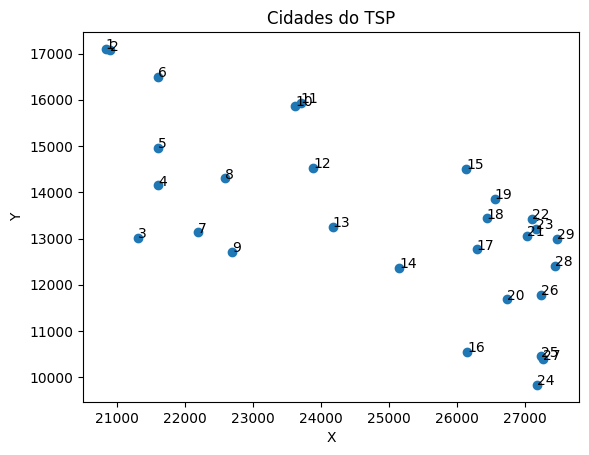

In [49]:
coords = ler_tsp_arquivo("tsp29.tsp")
plotar_cidades(coords)



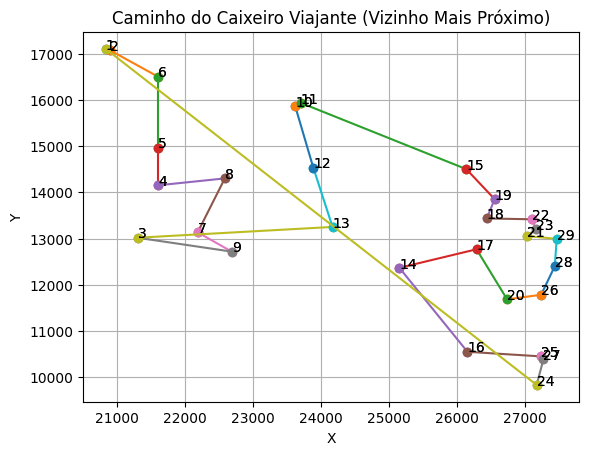

36388

In [50]:
caminho, arestas, peso = vizinho_mais_proximo(coords)
plotar_arestas(arestas)
peso